In [1]:
from typing import Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from deepagents.backends import FilesystemBackend
from deepagents.middleware.filesystem import FilesystemMiddleware

load_dotenv()

DATA_DIR = "../examples-data"

model = ChatOpenAI(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}},
    temperature=0.2,
)

/Users/zhengjie/Documents/learn-langgraph/.venv/lib/python3.14/site-packages/langchain_core/utils/pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
backend = FilesystemBackend(
    root_dir=DATA_DIR,
    virtual_mode=True,
)

SEARCH_MIDDLEWARE = FilesystemFileSearchMiddleware(
    root_path=str(DATA_DIR),
    use_ripgrep=True,
)
FS_TOOLS = ["ls", "read_file", "edit_file"]

EDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档目录结构整理专家。修改文件只能使用 edit_file。

## 工作流程

1. 使用 grep_search 检索文件中是否存在「目录」，检索时允许“目”和“录”之间存在空格；如果存在，读取该位置及其后少量内容以获取 TOC；如果不存在，则跳过 TOC。
2. 使用 grep_search 提取正文中全部 Markdown 标题及行号，pattern 固定为 `^#{1,6} `。
3. 比较 TOC 与正文标题结构；如果不存在 TOC，则按章节编号和上下级关系分析标题结构，一次性确认全部问题。
4. 使用 edit_file 修正标题层级，只修改标题相关内容。
5. 修改完成后再次使用 grep_search 提取标题并复核。

## 修改规则

- **按编号确定层级**：有明确章节编号时，按编号深度确定 Markdown 层级，如 `1`、`第一章` 使用 `#`，`1.1` 使用 `##`，`1.1.1` 使用 `###`。
- **参考 TOC 层级**：文档前部存在自带 TOC 时，优先参考 TOC 的章节关系和编号形式校对正文标题层级，不要盲从当前的 `#` 数量。
- **降级封面标题**：正文开头的文档封面大标题（如 `# XX方案`）不是章节，降级为 `**加粗**`。
- **降级"目录"二字所在行**：正文中字面为「目录」的一行（如 `## 目录`）不是章节标题，降级为 `**加粗**`。
- **补充缺失标题**：TOC 中有但正文未被解析为标题的章节（如仅加粗或遗漏 `#`），按 TOC 层级手动补充为 `#` 正文标题。
- **降级非 TOC 小标题**：正文内更细碎的编号（如"一、""1、""（1）""1.1.1.1.1"等），若未在 TOC 中出现，一律不用 `#` 标题，改为 `**加粗**`。
- **清理标题格式**：`#` 与标题文字之间保留一个半角空格。

最终目标：使 Markdown 标题结构合理一致，并能够稳定按照一级标题 `# ` 拆分章节。

除非为定位 TOC、确认待修改标题或执行明确修改所必需，否则不要读取正文；优先使用 grep_search 获取标题信息，禁止重复或大范围读取文件。

如果收到 Auditor 反馈，只处理其指出的问题，不重新扫描整个文档。
"""

editor_agent = create_agent(
    model,
    system_prompt=EDITOR_SYSTEM_PROMPT,
    middleware=[
        FilesystemMiddleware(backend=backend, tools=FS_TOOLS),
        SEARCH_MIDDLEWARE,
    ],
)

AUDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档结构审计员。只检查标题结构，不修改文件。

## 工作流程

1. 从当前 message 中确定目标 Markdown 文件。
2. 使用 grep_search 提取全部 Markdown 标题及行号，pattern 固定为 `^#{1,6} `。
3. 检查当前标题结构是否合理。
4. 输出结论后立即结束。

## 检查重点

- 标题层级是否合理、连续。
- 章节编号与 Markdown 层级是否匹配。
- 非章节小标题是否误用了 `#`。
- 封面标题和「目录」是否误用了 `#`。
- `#` 与标题文字之间是否保留一个半角空格。

最终确认 Markdown 能够稳定按照一级标题 `# ` 拆分为合理章节。

除非为确认具体审计问题所必需，否则不要读取正文；禁止重复或大范围读取文件。

## 输出

通过：简要说明，并以 `[AUDIT_PASS]` 结尾。

不通过：只列出确认存在的问题，包括行号、问题和建议修改方式，并以 `[AUDIT_FAIL]` 结尾。
"""

auditor_agent = create_agent(
    model,
    system_prompt=AUDITOR_SYSTEM_PROMPT,
    middleware=[
        FilesystemMiddleware(backend=backend, tools=FS_TOOLS),
        SEARCH_MIDDLEWARE,
    ],
)


class AgentState(BaseModel):
    """工作流状态：messages 承载 Editor 对话；不接入 checkpointer，单次运行即起即止。"""

    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    is_valid: bool = False
    attempts: int = 0
    audit_feedback: str = ""


def auditor_node(state: AgentState) -> dict:
    """审计并评估：计数、审计、打回逻辑全部收敛在本节点内。"""
    attempts = state.attempts + 1

    original_request = state.messages[0].content
    audit_message = HumanMessage(
        content=(
            "请执行一次独立的 Markdown 结构审计。\n\n"
            f"原始任务（用于确定目标文件）：{original_request}\n\n"
            f"Editor 已完成第 {attempts} 次修改，请直接检查上述目标文件。"
        )
    )
    result = auditor_agent.invoke({"messages": [audit_message]})
    feedback = result["messages"][-1].content.strip()

    if "[AUDIT_PASS]" in feedback:
        return {"attempts": attempts, "is_valid": True, "audit_feedback": feedback}

    retry_message = HumanMessage(
        name="Auditor",
        content=(
            f"第 {attempts} 次修改未通过审计。\n\n"
            f"审计反馈：\n{feedback}\n\n"
            "请严格按照上面的具体行号和问题，使用工具修复目标 Markdown 文件。"
        ),
    )
    return {
        "attempts": attempts,
        "is_valid": False,
        "audit_feedback": feedback,
        "messages": [retry_message],
    }


def should_continue(state: AgentState) -> str:
    if state.is_valid:
        return END

    if state.attempts >= 3:
        return "fail"

    return "editor"


def fail_node(state: AgentState) -> dict:
    raise RuntimeError(
        f"经过 {state.attempts} 次修改仍未通过审计，流程终止。\n"
        f"最后一次反馈：\n{state.audit_feedback}"
    )


builder = StateGraph(AgentState)

builder.add_node("editor", editor_agent)
builder.add_node("auditor", auditor_node)
builder.add_node("fail", fail_node)

builder.add_edge(START, "editor")
builder.add_edge("editor", "auditor")

builder.add_conditional_edges(
    "auditor",
    should_continue,
    {
        "editor": "editor",
        "fail": "fail",
        END: END,
    },
)

graph = builder.compile()

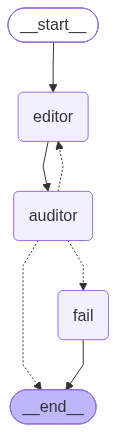

In [3]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
md_file = "油气管道地质灾害防护技术规范.md"
try:
    for chunk in graph.stream(
            {"messages": [HumanMessage(content=f"请检查并修正 Markdown 文件 `{md_file}` 的标题层级结构。")]},
            stream_mode="values",
            version="v2",
            subgraphs=True
    ):
        ns = chunk.get("ns") or ()
        print(ns[0].split(":")[0] if ns else "root")
        message = chunk["data"].messages[-1]  # data 是 AgentState(pydantic)，不是 dict
        message.pretty_print()

except RuntimeError as e:
    print(f"\n💥 流程终止：{e}")

print("\n🎉 审计通过，流程结束。")

root
================================ Human Message =================================

请检查并修正 Markdown 文件 `油气管道地质灾害防护技术规范.md` 的标题层级结构。
editor
================================ Human Message =================================

请检查并修正 Markdown 文件 `油气管道地质灾害防护技术规范.md` 的标题层级结构。
editor
================================== Ai Message ==================================
Tool Calls:
  ls (call_00_G3X5bW7QvQwlNafGz2M51673)
 Call ID: call_00_G3X5bW7QvQwlNafGz2M51673
  Args:
    path: /
editor
================================= Tool Message =================================
Name: ls

['/.DS_Store', '/Chinook.db', '/layout-parser-paper.pdf', '/nke-10k-2023.pdf', '/油气管道地质灾害防护技术规范.md', '/详细设计.md']
editor
================================== Ai Message ==================================
Tool Calls:
  grep_search (call_00_vgB3duOEwMdu9PvnAdL82619)
 Call ID: call_00_vgB3duOEwMdu9PvnAdL82619
  Args:
    pattern: 目\s*录
    path: /油气管道地质灾害防护技术规范.md
    output_mode: content
  grep_search (call_01_cdUbFLPAYY832yN09T